In [ ]:
# Decision Tree
"""
A Decision Tree is a supervised machine learning algorithm that can be used for both:
    Classification Problems
    Regression Problems
However, it is mostly preferred for classification tasks because it is easy to understand and interpret.

CART Algorithm
To build a Decision Tree, we commonly use the CART (Classification and Regression Tree) Algorithm.
CART = Classification And Regression Tree
    Used for Classification → Output is a category (Yes/No, Spam/Not Spam)
    Used for Regression → Output is a numerical value

Types of Data
1. Linearly Separable Data
Data can be separated using a single straight line.
example 
● ● ● ● ●

----------------

▲ ▲ ▲ ▲ ▲

2. Non-Linearly Separable Data
Data cannot be separated using a single straight line.
Example:
      ▲ ▲
   ▲ ● ● ▲
  ▲ ● ● ● ▲
   ▲ ● ● ▲
      ▲ ▲
A curved boundary or multiple splits are required.

"""

In [ ]:
# Structure of a Decision Tree
"""
Example Tree:
                Root Node
                    |
            Decision Node
             /          \
     Decision Node      Leaf Node
       /      \
 Leaf Node   Decision Node
             /        \
        Leaf Node   Leaf Node

Representation
- Root Node → Starting node of the tree
- Decision Node → Node that further splits
- Leaf Node → Final output node
- Subtree → Portion of the complete tree

"""

In [ ]:
"""
Example Decision Tree
Conditions
    Company = Amazon, Flipkart, Boat
    Job = Python, SQL, Django
    Degree = Bachelor, Masters
Rule:
If Company = Amazon
    If Job = Python
        If Degree = Bachelor
            Print No
        Else
            Print Yes

Complete Decision Tree
                           Company
                   /          |          \
              Amazon      Flipkart       Boat
                 |
                Job
          /      |      \
      Python    SQL    Django
         |
      Degree
      /     \
Bachelor   Masters
   |           |
  No          Yes


"""

In [ ]:
# Important Terminologies
"""
1. Root Node
The root node represents the entire population or sample.
It is the top-most node from which the tree starts.
Here, Company is the root node.

2. Splitting
The process of dividing a node into two or more subnodes.
Example:

      Company
      /  |  \
 Amazon Flipkart Boat
Company is split into three subnodes.

3. Decision Node
A node that further splits into other subnodes.
Example:

      Job
    /  |  \
 Python SQL Django
Job is a decision node.

4. Leaf (Terminal) Node
A node that does not split further.
Example:
 Bachelor → No
 Masters  → Yes
No and Yes are leaf nodes.

5. Pruning
The process of removing unnecessary branches from a decision tree to reduce overfitting.
Before Pruning:

       A
      / \
     B   C
    /
   D

After Pruning:

      A
     / \
    B   C

Node D is removed.

6. Branch / Subtree
A section of the entire decision tree.

Example:
Company
   |
  Job
   |
Degree
This portion forms a subtree.

7. Parent and Child Node
Example:

      Company
         |
        Job
Company → Parent Node
Job → Child Node
"""

In [ ]:
# Attribute Selection Measure (ASM)
"""
ASM is used to select the best feature for splitting a node.
Two popular techniques are:
- Information Gain
- Entropy

Desired Condition 
| Measure          | Preference |
| ---------------- | ---------- |
| Information Gain | Higher     |
| Entropy          | Lower      |
""

In [ ]:
# Entropy
"""
Entropy is a metric used to measure impurity or randomness in the dataset.

Formula
Entropy(S)=−i=1∑n​Pi​log2​(Pi​)
For binary classifier
Entropy(S)= −P(Yes)log2​(P(Yes))−P(No)log2​(P(No))
Where:
P(Yes) = Probability of Yes
P(No) = Probability of No
S = Total Samples

Entropy Interpretation
| Entropy         | Meaning          |
| --------------- | ---------------- |
| 0               | Pure Node        |
| 1               | Maximum Impurity |
| Between 0 and 1 | Partial Impurity |

"""

In [ ]:
# Information Gain
"""
Information Gain measures the reduction in entropy after splitting a dataset.
It tells us how useful a feature is for classification.
Formula : Information Gain=Entropy(S)−∑(Weighti​×Entropyi​)

IG(S,A)=Entropy(S)−v∈Values(A)∑​∣S∣∣Sv​∣​×Entropy(Sv​)
where
S = Dataset
A = Attribute
Sv= Subset after split
Weight = Proportion of samples

Interpretation
- Higher Information Gain → Better Attribute
- Lower Information Gain → Poor Attribute
The attribute with the highest information gain is selected as the split node.

"""

In [ ]:
# Gini Index
"""
The Gini Index is another measure of impurity used while building a Decision Tree.
It is mainly used in the CART Algorithm.
Formula 
Gini(S)=1−∑Pi2​
For Binary Classification:
Gini(S)=1−(P(Yes)2+P(No)2)

Interpretation
| Gini Value | Meaning       |
| ---------- | ------------- |
| 0          | Pure Node     |
| Close to 0 | Better Split  |
| High Value | More Impurity |


Gini Index in CART
While building a CART Decision Tree:
Choose the attribute with the Lowest Gini Index
Avoid attributes with a High Gini Index
Rule
    Lower Gini Index  → Better Split
    Higher Gini Index → Poor Split

"""

In [ ]:
# Short 
"""
Entropy = Measures impurity/randomness
Information Gain = Reduction in entropy after split
Gini Index = Measures impurity (used in CART)

Entropy → Lower is better
Information Gain → Higher is better
Gini Index → Lower is better
"""

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

In [4]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head(3)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0


In [5]:
dataset.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [17]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [22]:
from sklearn.model_selection import train_test_split
x_train , x_test,y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier() #criterion : {"gini", "entropy", "log_loss"}
dt.fit(x_train , y_train)
dt.score(x_test, y_test)*100

83.75

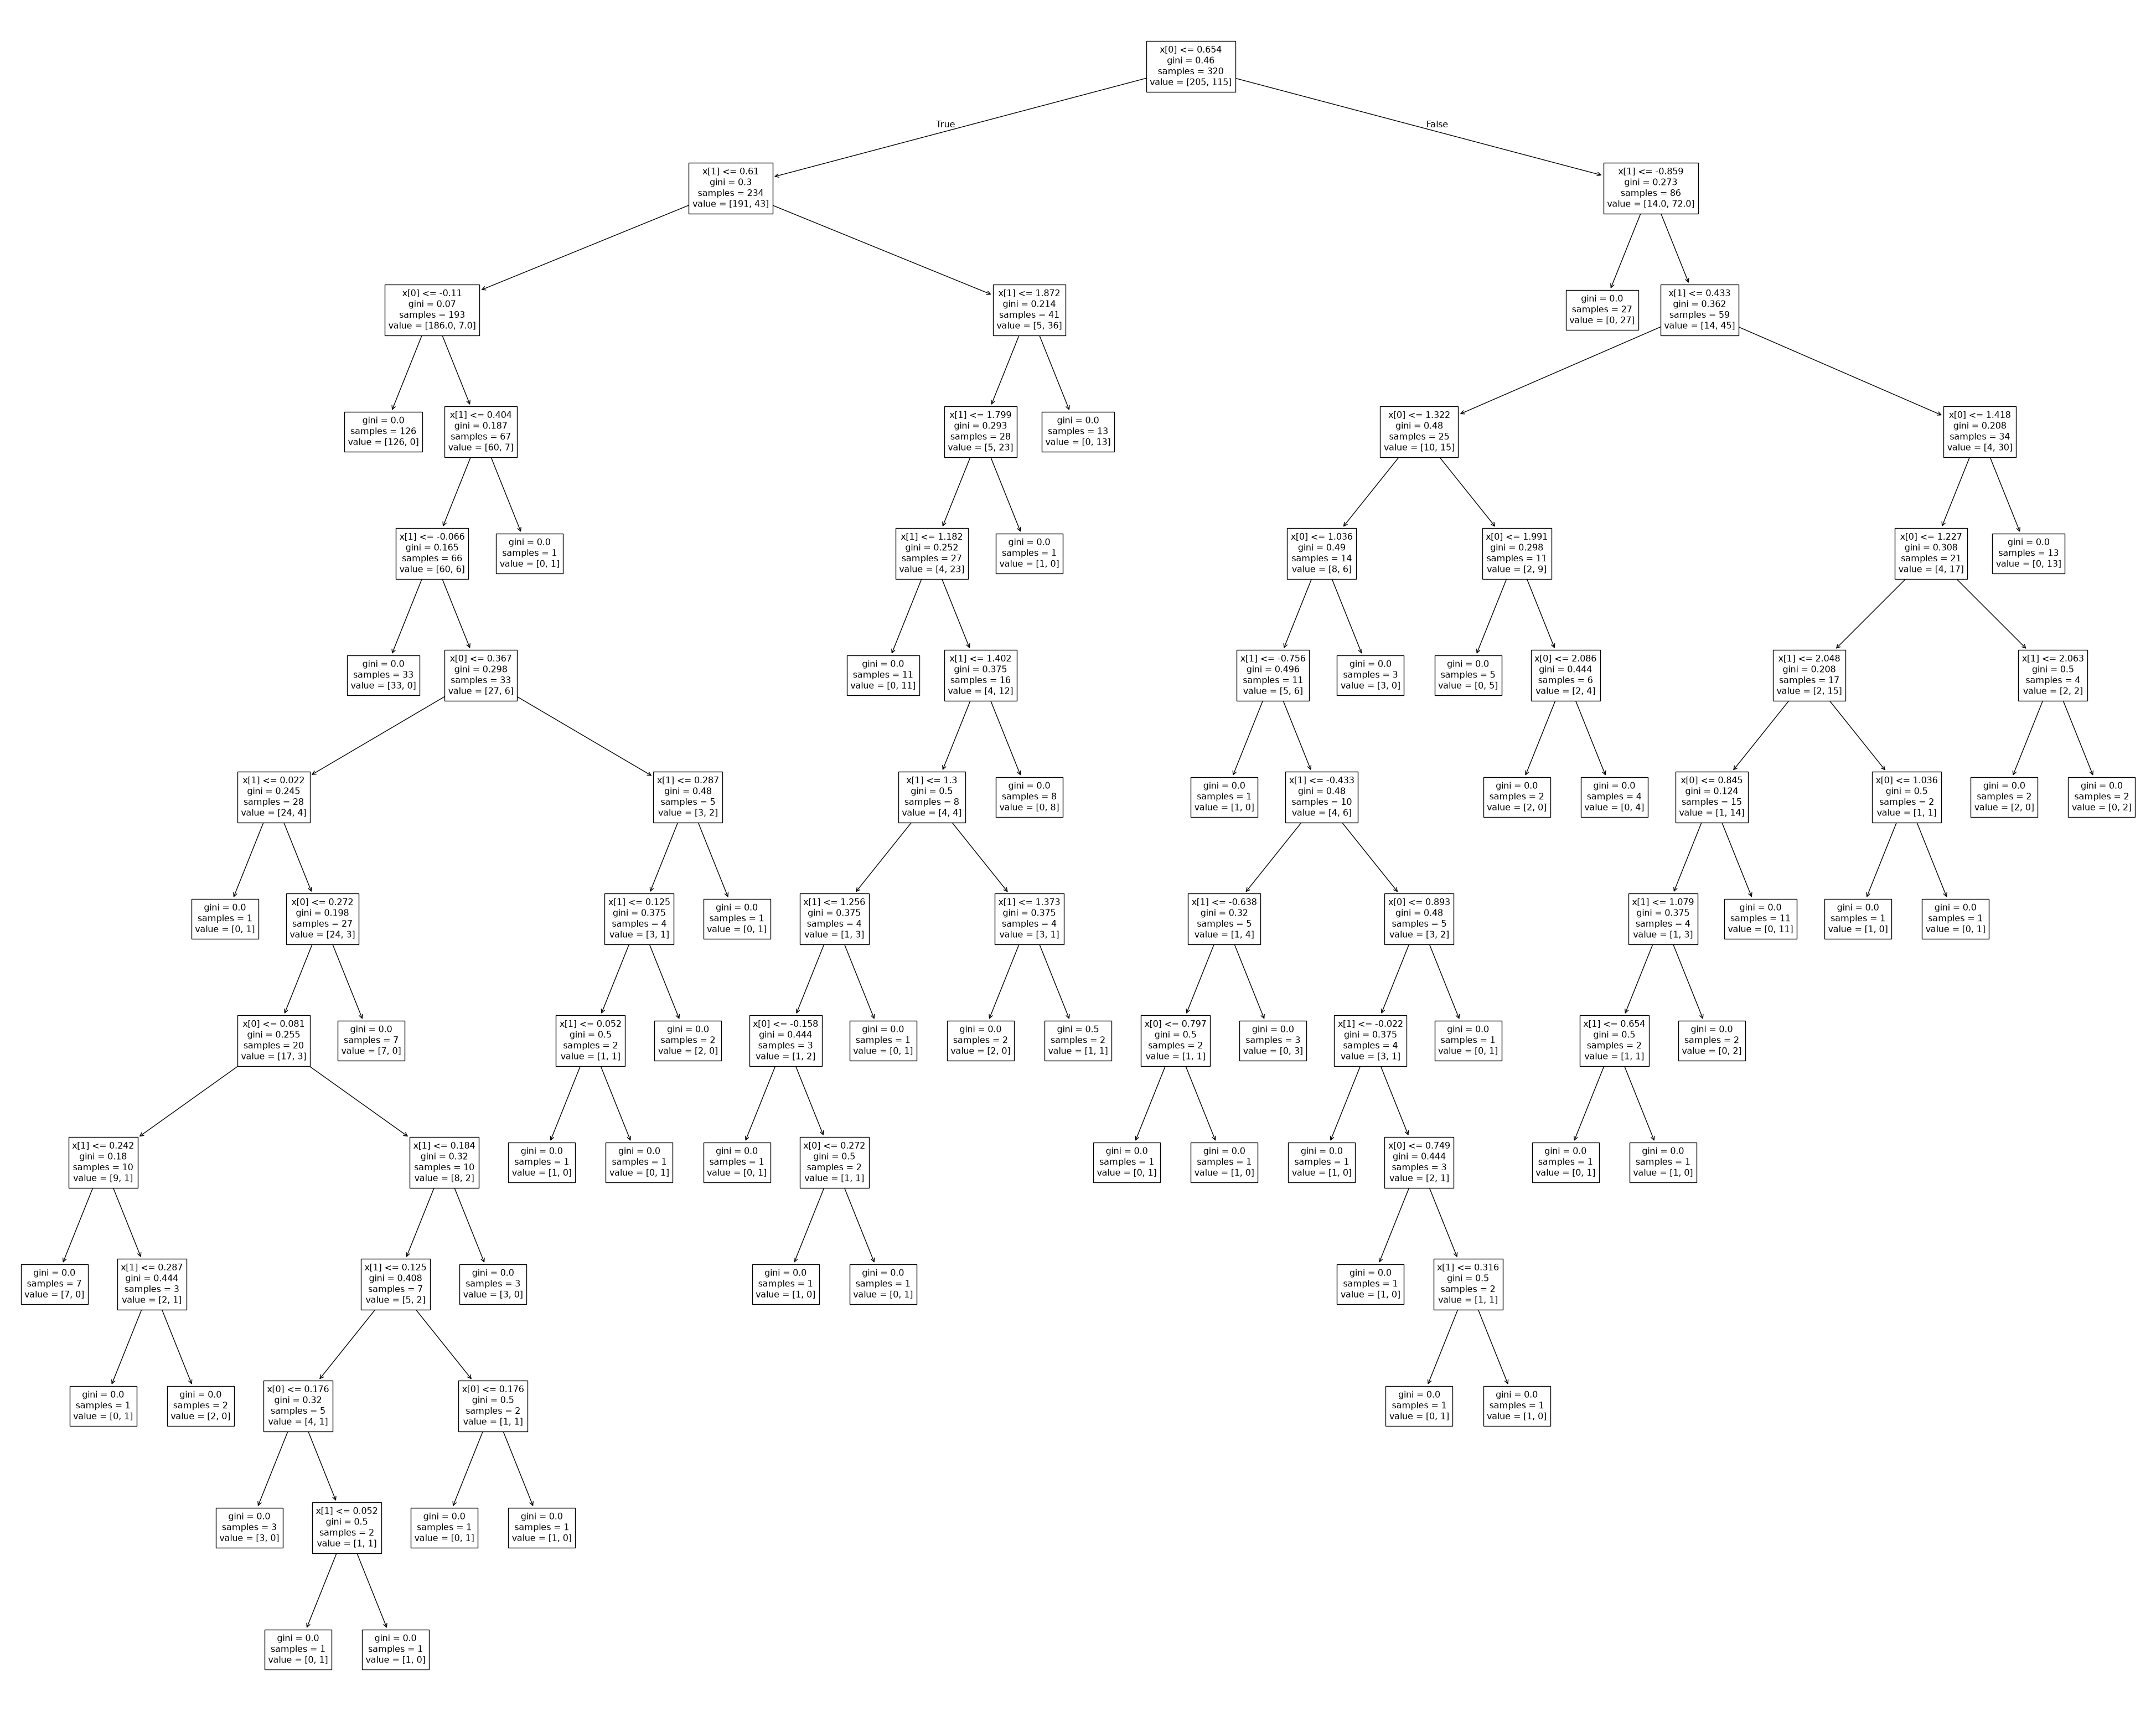

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize=(50,40))
plot_tree(dt)
plt.savefig("DecisionTreeClassifier.jpg")
plt.show()

In [30]:
dt1 = DecisionTreeClassifier(criterion="entropy") #criterion : {"gini", "entropy", "log_loss"}
dt1.fit(x_train , y_train)
dt1.score(x_test, y_test)*100

83.75

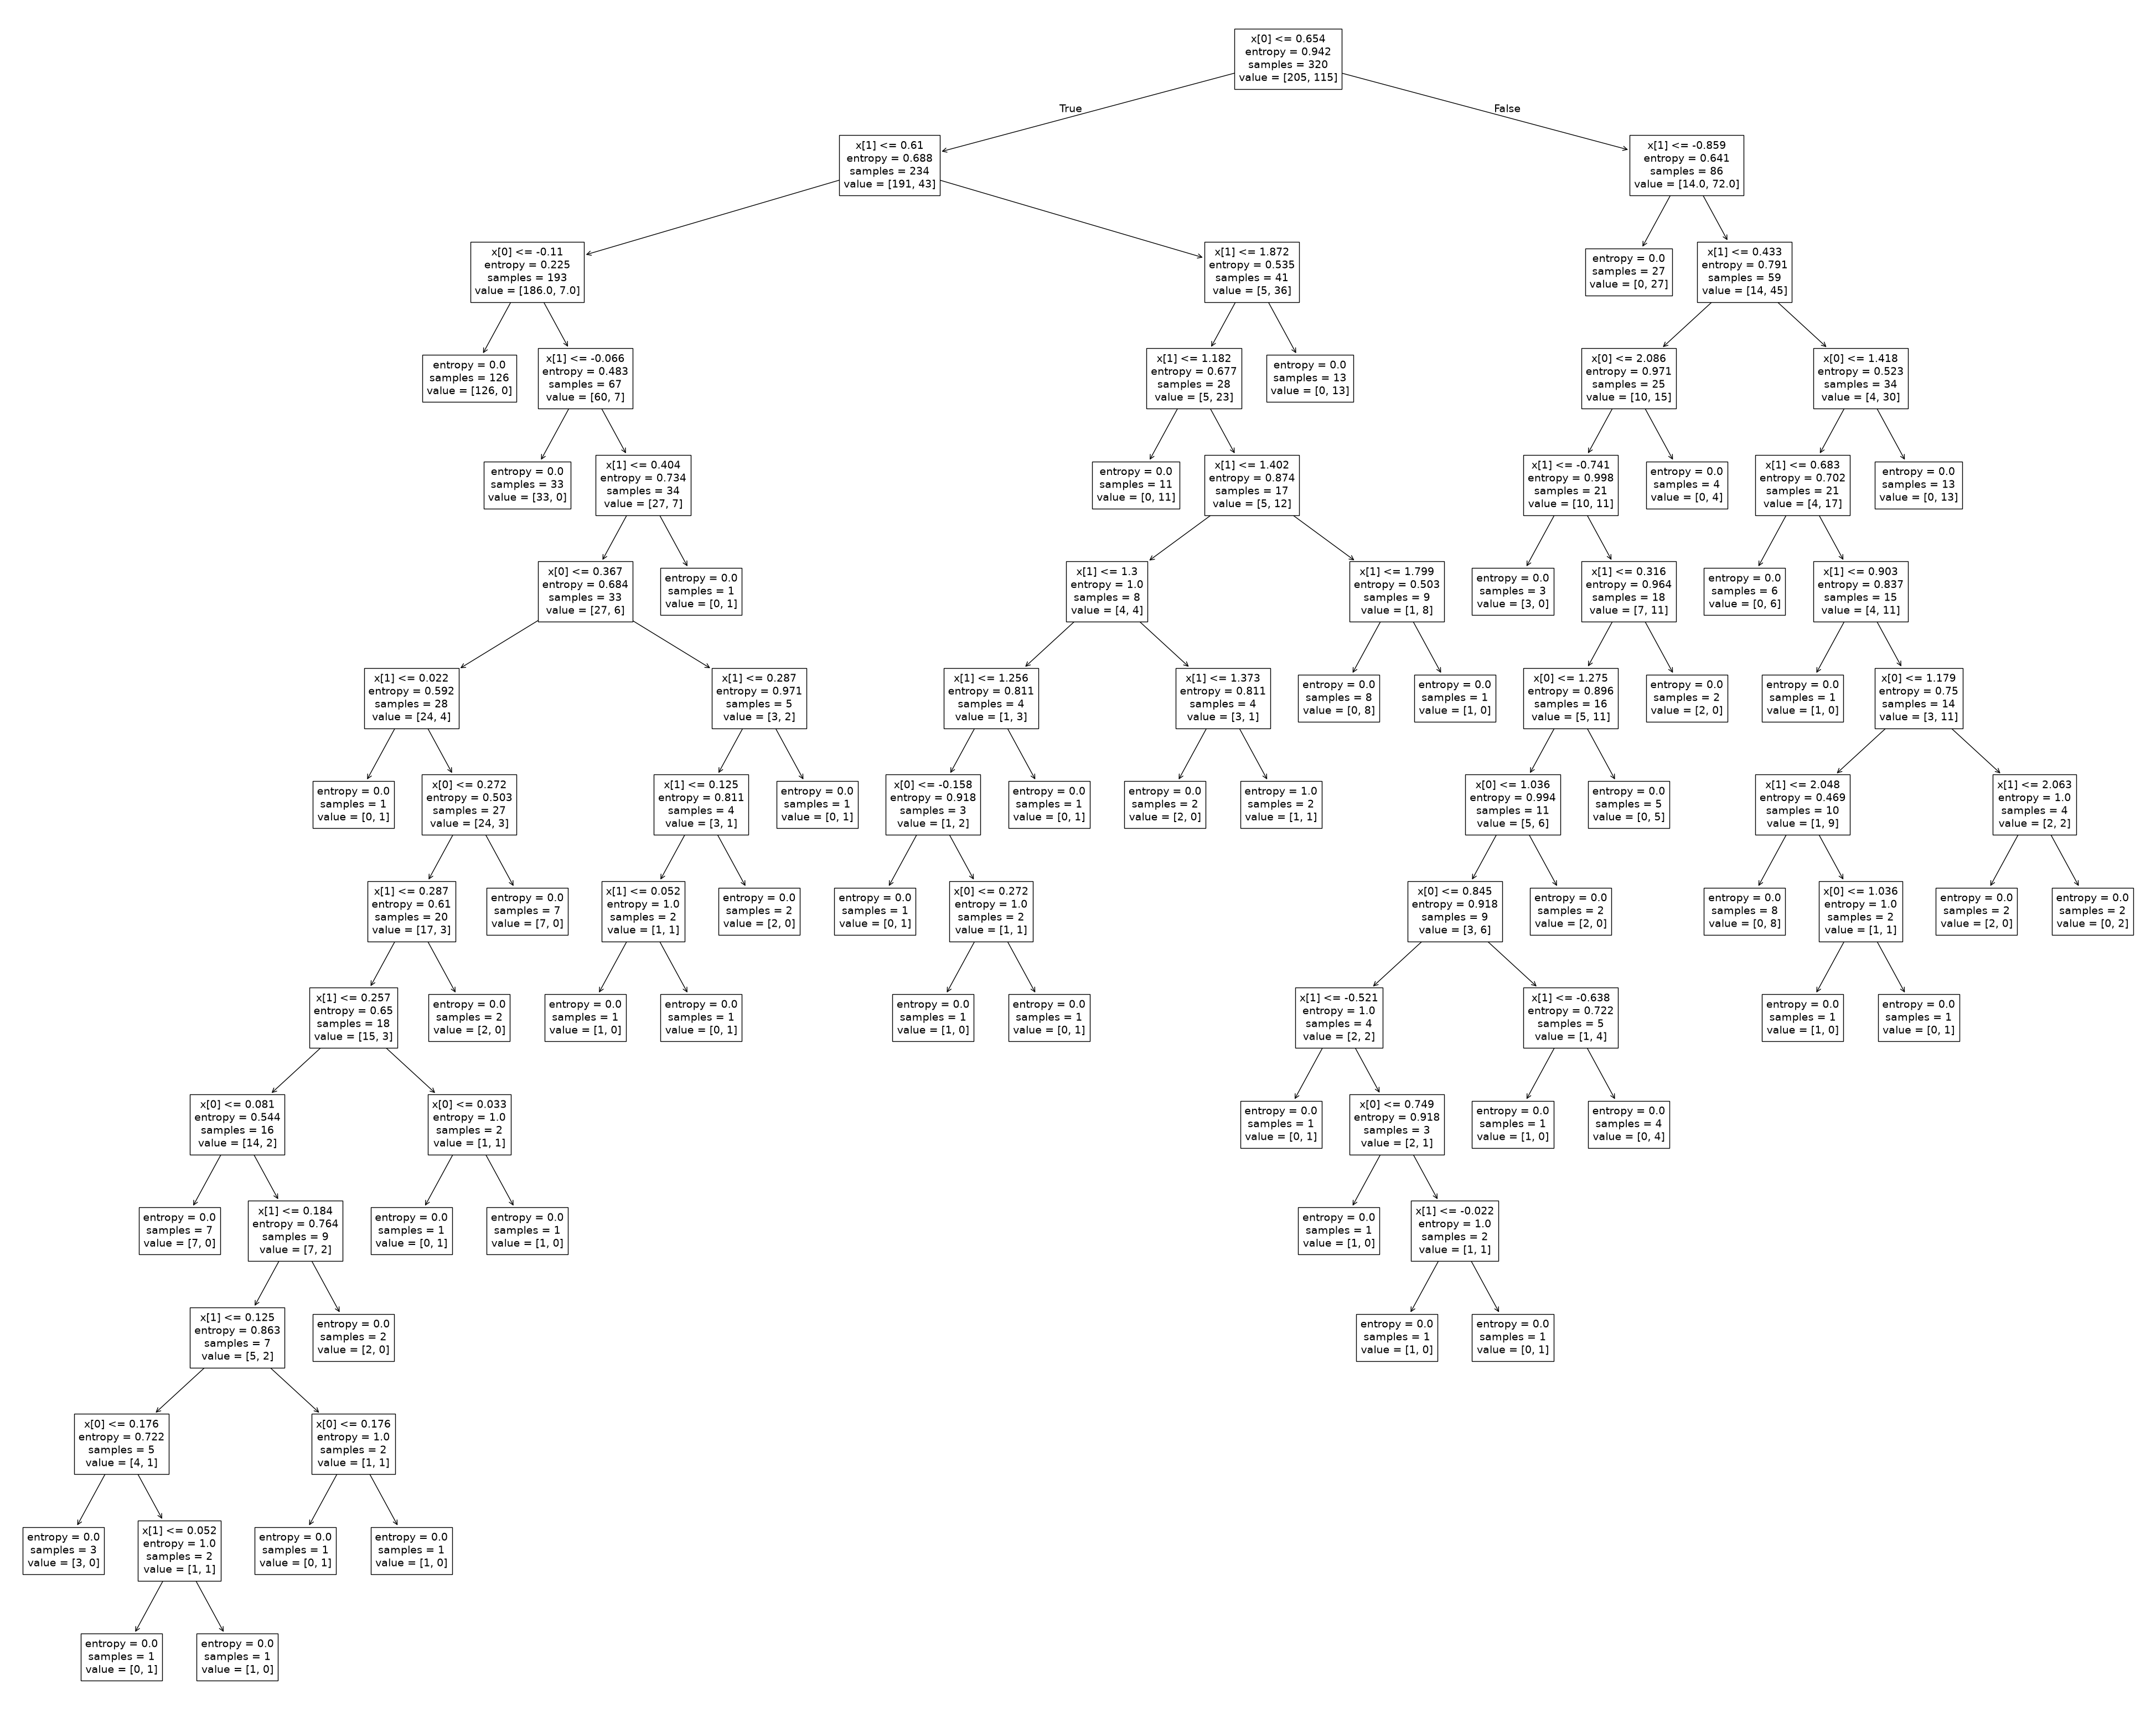

In [31]:
plt.figure(figsize=(50,40))
plot_tree(dt1)
plt.show()

In [32]:
dt2 = DecisionTreeClassifier(criterion="log_loss")
dt2.fit(x_train , y_train)
dt2.score(x_test, y_test)*100

83.75

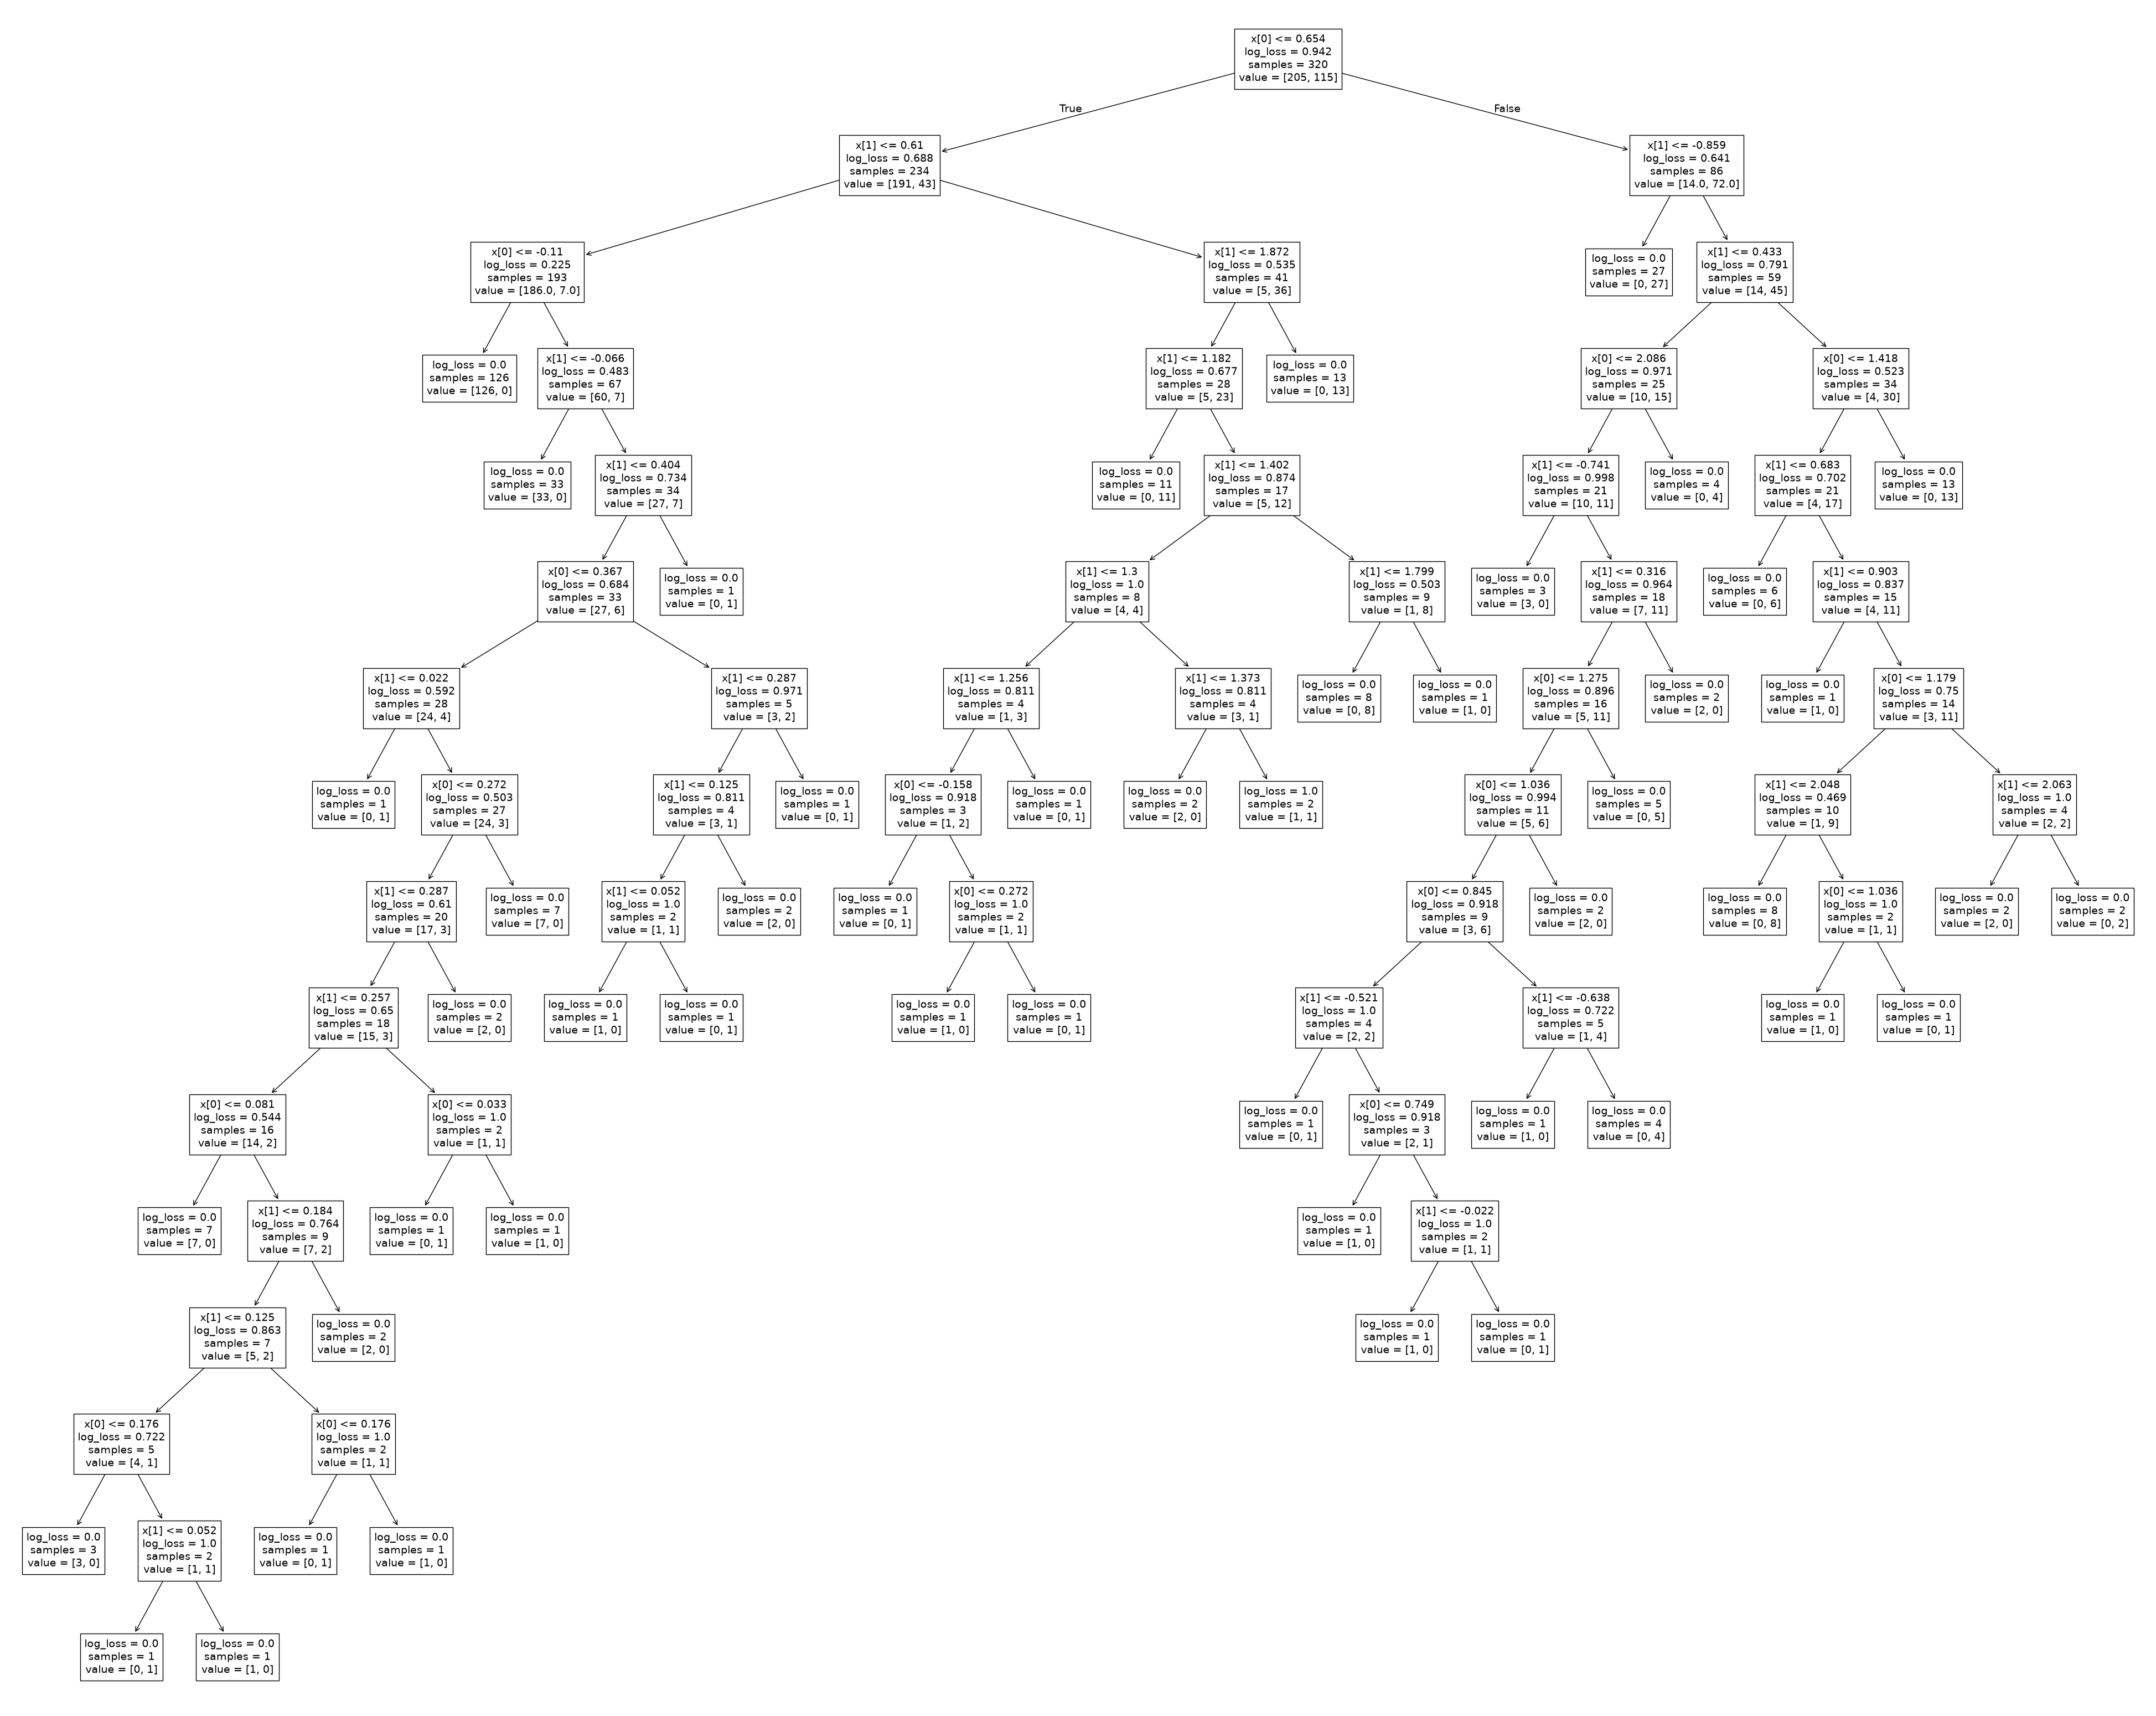

In [33]:
plt.figure(figsize=(50,40))
plot_tree(dt2)
plt.show()

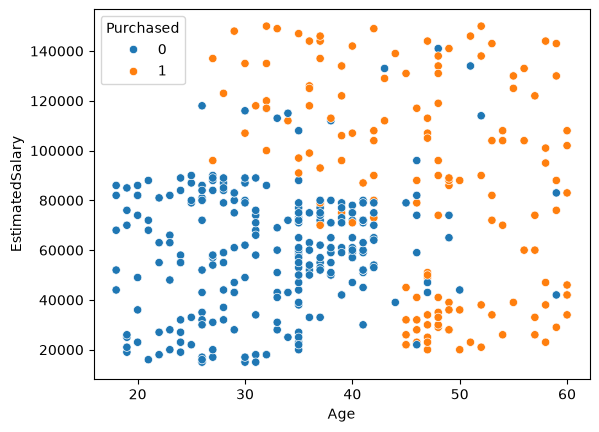

In [34]:
sns.scatterplot(x="Age", y="EstimatedSalary",data=dataset,hue="Purchased")
plt.show()

C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


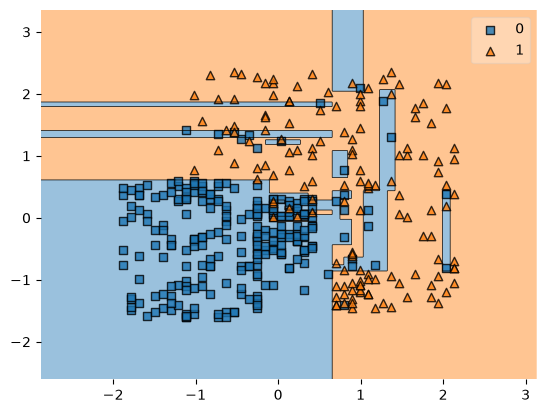

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dt)
plt.show()

C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


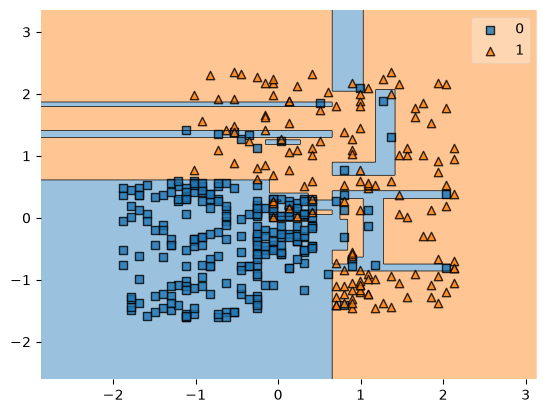

In [36]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dt1)
plt.show()

C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


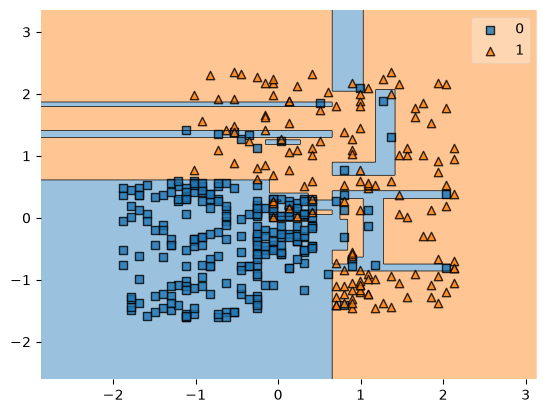

In [37]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dt2)
plt.show()

In [ ]:
"""
Pruning
Pruning is used in Decision Trees to reduce overfitting and make the model generalize better on unseen data.
When a tree grows too deep, it starts learning noise → this reduces test accuracy. Pruning fixes that.

Pre-Pruning (Early Stopping)
Pre-pruning means stopping the tree from growing BEFORE it becomes too complex.
You control the growth while building the tree.
dt = DecisionTreeClassifier(max_depth=3)

Post-Pruning (Cost Complexity Pruning)
Post-pruning means first growing a FULL tree, then cutting unwanted branches after training.
So:
👉 Build full tree → then remove weak branches

for i in range(1,20):
    dt2 = DecisionTreeClassifier(max_depth=i)
    dt2.fit(x_train,y_train)
    print(dt2.score(x_train,y_train),stz.score(x_test,y_test))
"""